In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

from google.colab import userdata

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [2]:
!pip install wandb kaggle --upgrade
import torch, torch.nn as nn
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import wandb
from google.colab import userdata

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.8/132.8 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.0/231.0 kB 15.3 MB/s eta 0:00:00
  Attempting uninstall: kagglesdk
    Found existing installation: kagglesdk 0.1.23
    Uninstalling kagglesdk-0.1.23:
      Successfully uninstalled kagglesdk-0.1.23
  Attempting uninstall: kaggle
    Found existing installation: kaggle 2.0.2
    Uninstalling kaggle-2.0.2:
      Successfully uninstalled kaggle-2.0.2


In [3]:
import os
os.environ['KAGGLE_API_TOKEN'] = userdata.get('KAGGLE_KEY')
!kaggle competitions download -c challenges-in-representation-learning-facial-expression-recognition-challenge
!unzip -q *.zip
!ls

100% 285M/285M [00:02<00:00, 130MB/s]

challenges-in-representation-learning-facial-expression-recognition-challenge.zip
example_submission.csv
fer2013.tar.gz
icml_face_data.csv
sample_data
test.csv
train.csv


In [4]:
wandb.login(key=userdata.get('WANDB_API_KEY'))

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: lkuch23 (lkuch23-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [5]:
TOKEN = userdata.get('GITHUB_TOKEN')
REPO = f"https://{TOKEN}@github.com/lizikutchava/ml_assn4"

!git init
!git remote add origin {REPO}
!git branch -M main
!git config --global user.email "lkuch23@freeuni.edu.ge"
!git config --global user.name "lizikutchava"

hint: Using 'master' as the name for the initial branch. This default branch name
hint: is subject to change. To configure the initial branch name to use in all
hint: of your new repositories, which will suppress this warning, call:
hint: 
hint: 	git config --global init.defaultBranch <name>
hint: 
hint: Names commonly chosen instead of 'master' are 'main', 'trunk' and
hint: 'development'. The just-created branch can be renamed via this command:
hint: 
hint: 	git branch -m <name>
Initialized empty Git repository in /content/.git/


In [6]:
!git branch -M main
!git remote set-url origin {REPO}

Shape: (28709, 2)

Columns: ['emotion', 'pixels']

Emotion split:
emotion
0    3995
1     436
2    4097
3    7215
4    4830
5    3171
6    4965
Name: count, dtype: int64


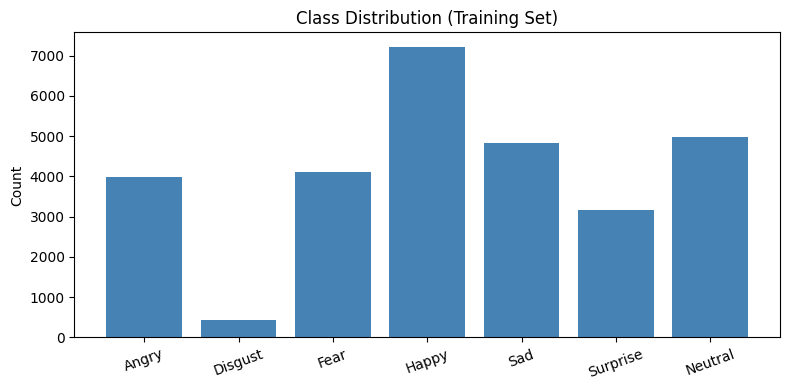

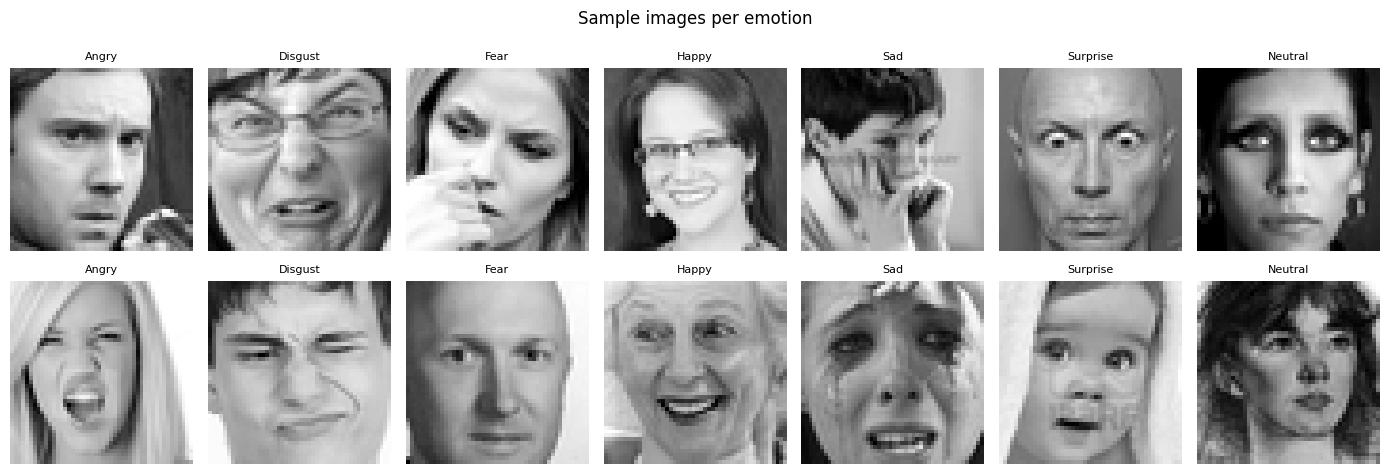

In [7]:
df = pd.read_csv('train.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nEmotion split:")
print(df['emotion'].value_counts().sort_index())

EMOTION_LABELS = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

plt.figure(figsize=(8, 4))
counts = df['emotion'].value_counts().sort_index()
plt.bar([EMOTION_LABELS[i] for i in counts.index], counts.values, color='steelblue')
plt.title('Class Distribution (Training Set)')
plt.ylabel('Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 7, figsize=(14, 5))
for emotion_idx, ax in enumerate(axes[0]):
    sample = df[df['emotion'] == emotion_idx].iloc[0]
    pixels = np.array(sample['pixels'].split(), dtype=np.float32).reshape(48, 48)
    ax.imshow(pixels, cmap='gray')
    ax.set_title(EMOTION_LABELS[emotion_idx], fontsize=8)
    ax.axis('off')
for emotion_idx, ax in enumerate(axes[1]):
    sample = df[df['emotion'] == emotion_idx].iloc[5]
    pixels = np.array(sample['pixels'].split(), dtype=np.float32).reshape(48, 48)
    ax.imshow(pixels, cmap='gray')
    ax.set_title(EMOTION_LABELS[emotion_idx], fontsize=8)
    ax.axis('off')
plt.suptitle('Sample images per emotion', fontsize=12)
plt.tight_layout()
plt.show()

In [8]:
from sklearn.model_selection import train_test_split

class FERDataset(Dataset):
    def __init__(self, dataframe, transform=None, has_labels=True):
        self.data = dataframe.reset_index(drop=True)
        self.transform = transform
        self.has_labels = has_labels
        if has_labels:
            self.labels = self.data['emotion'].values
        self.images = [
            np.array(row.split(), dtype=np.float32).reshape(48, 48)
            for row in self.data['pixels']
        ]

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        image = self.images[idx]
        image = image / 255.0
        image = torch.tensor(image, dtype=torch.float32).unsqueeze(0)
        if self.transform:
            image = self.transform(image)
        if self.has_labels:
            return image, int(self.labels[idx])
        else:
            return image, -1


def get_dataloaders(batch_size=64, augment=True):
    df      = pd.read_csv('train.csv')
    test_df = pd.read_csv('test.csv')

    train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['emotion'])
    print(f"Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

    if augment:
        train_transform = transforms.Compose([
            transforms.RandomHorizontalFlip(p=0.5),
            transforms.RandomRotation(degrees=10),
            transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
        ])
    else:
        train_transform = None

    train_dataset = FERDataset(train_df, transform=train_transform, has_labels=True)
    val_dataset   = FERDataset(val_df,   transform=None,            has_labels=True)
    test_dataset  = FERDataset(test_df,  transform=None,            has_labels=False)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader


train_loader, val_loader, test_loader = get_dataloaders(batch_size=64)
imgs, labels = next(iter(train_loader))
print(f'Batch shape: {imgs.shape}, Labels shape: {labels.shape}')
print(f'Train batches: {len(train_loader)}, Val batches: {len(val_loader)}')

Train: 22967, Val: 5742, Test: 7178
Batch shape: torch.Size([64, 1, 48, 48]), Labels shape: torch.Size([64])
Train batches: 359, Val batches: 90


=== Exp 1: TinyCNN (underfitting baseline) ===
Forward pass - output shape torch.Size([4, 7])
Backward pass - 8 tensors have gradients
Overfit check - loss 2.1362 -> 0.0000
Train: 22967, Val: 5742, Test: 7178


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.



  exp1_TinyCNN
Ep   1/30 | Train 1.6977/0.3189 | Val 1.6074/0.3802 | Gap -0.0613
Ep   5/30 | Train 1.4197/0.4528 | Val 1.4179/0.4617 | Gap -0.0089
Ep  10/30 | Train 1.2577/0.5188 | Val 1.3389/0.4923 | Gap +0.0265
Ep  15/30 | Train 1.1326/0.5759 | Val 1.3232/0.5051 | Gap +0.0709
Ep  20/30 | Train 1.0329/0.6183 | Val 1.3280/0.5052 | Gap +0.1131
Ep  25/30 | Train 0.9692/0.6445 | Val 1.3353/0.5024 | Gap +0.1421
Ep  30/30 | Train 0.9480/0.6550 | Val 1.3361/0.5038 | Gap +0.1512


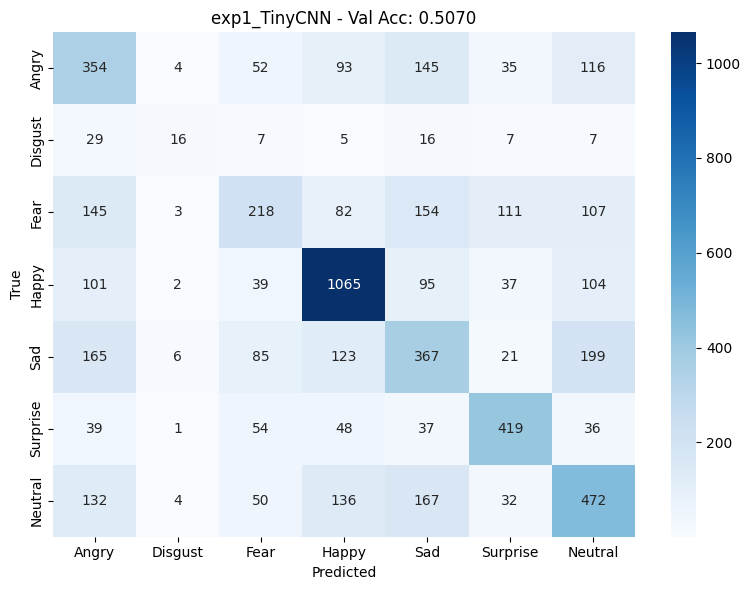


 Best val acc: 0.5070


epoch,▁▁▁▂▂▂▂▃▃▃▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇███
lr,█████▇▇▇▇▆▆▆▅▅▅▄▄▃▃▃▂▂▂▂▁▁▁▁▁▁
per_class/Angry_f1,▁
per_class/Disgust_f1,▁
per_class/Fear_f1,▁
per_class/Happy_f1,▁
per_class/Neutral_f1,▁
per_class/Sad_f1,▁
per_class/Surprise_f1,▁
train/acc,▁▂▃▄▄▄▄▅▅▅▅▆▆▆▆▇▇▇▇▇▇▇████████
+4,...


Exp1 best val acc: 0.5070


In [9]:
# MODEL 1: Tiny CNN
class TinyCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 12 * 12, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x


def forward_backward_check(model, device, name):
    model = model.to(device).train()
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    x = torch.randn(4, 1, 48, 48, device=device)
    y = torch.randint(0, 7, (4,), device=device)

    logits = model(x)
    assert logits.shape == (4, 7), f"Wrong shape: {logits.shape}"
    print(f"Forward pass - output shape {logits.shape}")

    loss = criterion(logits, y)
    loss.backward()
    grad_norms = [p.grad.norm().item() for p in model.parameters() if p.grad is not None]
    assert len(grad_norms) > 0, "No gradients!"
    print(f"Backward pass - {len(grad_norms)} tensors have gradients")

    x_s = torch.randn(8, 1, 48, 48, device=device)
    y_s = torch.zeros(8, dtype=torch.long, device=device)
    initial_loss = None
    for step in range(20):
        optimizer.zero_grad()
        out = model(x_s)
        l = criterion(out, y_s)
        l.backward()
        optimizer.step()
        if step == 0:
            initial_loss = l.item()
    assert l.item() < initial_loss, "Loss did not decrease!"
    print(f"Overfit check - loss {initial_loss:.4f} -> {l.item():.4f}")


def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = correct = total = 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        total_loss += loss.item() * images.size(0)
        correct += (outputs.argmax(1) == labels).sum().item()
        total += images.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = correct = total = 0
    all_preds, all_labels = [], []
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)
        total_loss += loss.item() * images.size(0)
        preds = outputs.argmax(1)
        correct += (preds == labels).sum().item()
        total += images.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


os.makedirs('checkpoints', exist_ok=True)

def train_model(model, config, train_loader, val_loader, experiment_name):
    run = wandb.init(project='fer2013-challenge', name=experiment_name, config=config, reinit=True)
    wandb.watch(model, log='all', log_freq=50)

    model = model.to(DEVICE)
    criterion = nn.CrossEntropyLoss(label_smoothing=config.get('label_smoothing', 0.0))

    opt = config.get('optimizer', 'adamw')
    lr  = config['lr']
    wd  = config.get('weight_decay', 1e-4)
    if opt == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=wd)
    elif opt == 'adamw':
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    elif opt == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=lr, momentum=0.9, weight_decay=wd)

    epochs = config['epochs']
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_val_acc = 0.0
    patience_counter = 0
    early_stop = config.get('early_stop_patience', 15)
    history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

    print(f"\n{'='*60}\n  {experiment_name}\n{'='*60}")

    for epoch in range(1, epochs + 1):
        train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, DEVICE)
        scheduler.step()

        gap = train_acc - val_acc
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)

        wandb.log({
            'epoch': epoch,
            'train/loss': train_loss, 'train/acc': train_acc,
            'val/loss':   val_loss,   'val/acc':   val_acc,
            'train_val_gap': gap,
            'lr': optimizer.param_groups[0]['lr'],
        }, step=epoch)

        if epoch % 5 == 0 or epoch == 1:
            print(f"Ep {epoch:3d}/{epochs} | Train {train_loss:.4f}/{train_acc:.4f} | "
                  f"Val {val_loss:.4f}/{val_acc:.4f} | Gap {gap:+.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save(model.state_dict(), f'checkpoints/best_{experiment_name}.pth')
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= early_stop:
            print(f"  Early stop at epoch {epoch}")
            break

    model.load_state_dict(torch.load(f'checkpoints/best_{experiment_name}.pth', map_location=DEVICE))
    _, final_val_acc, final_preds, final_labels = evaluate(model, val_loader, criterion, DEVICE)

    from sklearn.metrics import confusion_matrix, classification_report
    import seaborn as sns
    cm = confusion_matrix(final_labels, final_preds)
    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=EMOTION_LABELS, yticklabels=EMOTION_LABELS, ax=ax)
    ax.set_title(f'{experiment_name} - Val Acc: {final_val_acc:.4f}')
    ax.set_ylabel('True'); ax.set_xlabel('Predicted')
    plt.tight_layout()
    wandb.log({'confusion_matrix': wandb.Image(fig)})
    plt.show(); plt.close(fig)

    report = classification_report(final_labels, final_preds, target_names=EMOTION_LABELS, output_dict=True)
    for emotion in EMOTION_LABELS:
        wandb.log({f'per_class/{emotion}_f1': report[emotion]['f1-score']})

    wandb.summary['best_val_acc'] = best_val_acc
    wandb.summary['experiment']   = experiment_name
    print(f"\n Best val acc: {best_val_acc:.4f}")
    run.finish()
    return history, best_val_acc


print("=== Exp 1: TinyCNN (underfitting baseline) ===")
forward_backward_check(TinyCNN(), DEVICE, 'TinyCNN')

train_loader, val_loader, test_loader = get_dataloaders(batch_size=64, augment=False)

config_exp1 = {
    'architecture': 'TinyCNN',
    'epochs': 30,
    'lr': 1e-3,
    'optimizer': 'adam',
    'weight_decay': 1e-4,
    'batch_size': 64,
    'augmentation': False,
    'label_smoothing': 0.0,
    'early_stop_patience': 30,
    'expected_behavior': 'underfitting',
    'notes': 'Too small - proves we need more capacity. Both train and val acc plateau ~40%.'
}

hist1, acc1 = train_model(TinyCNN(), config_exp1, train_loader, val_loader, 'exp1_TinyCNN')
print(f"Exp1 best val acc: {acc1:.4f}")


=== Exp 2: DeepCNN (overfitting demo) ===
Forward pass - output shape torch.Size([4, 7])
Backward pass - 18 tensors have gradients
Overfit check - loss 1.9454 -> 0.0000
Train: 22967, Val: 5742, Test: 7178



  exp2_DeepCNN_overfit
Ep   1/40 | Train 1.7766/0.2690 | Val 1.7000/0.3121 | Gap -0.0431
Ep   5/40 | Train 1.1782/0.5479 | Val 1.2439/0.5256 | Gap +0.0223
Ep  10/40 | Train 0.3523/0.8739 | Val 2.1184/0.5441 | Gap +0.3299
Ep  15/40 | Train 0.0972/0.9698 | Val 3.4483/0.5343 | Gap +0.4355
Ep  20/40 | Train 0.0403/0.9892 | Val 4.3030/0.5397 | Gap +0.4495
Ep  25/40 | Train 0.0124/0.9961 | Val 5.2021/0.5418 | Gap +0.4543
Ep  30/40 | Train 0.0060/0.9975 | Val 4.7908/0.5465 | Gap +0.4510
Ep  35/40 | Train 0.0041/0.9976 | Val 5.1867/0.5489 | Gap +0.4487
Ep  40/40 | Train 0.0033/0.9983 | Val 5.3570/0.5484 | Gap +0.4498


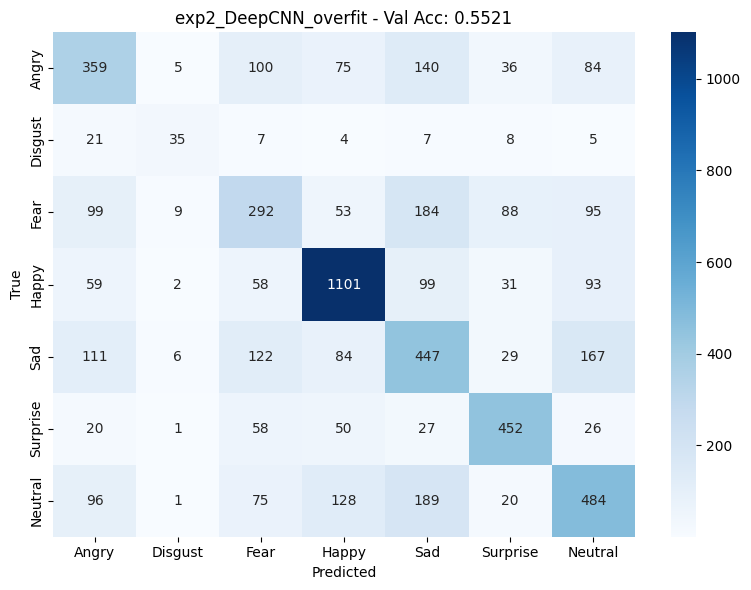


 Best val acc: 0.5521


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,██████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
per_class/Angry_f1,▁
per_class/Disgust_f1,▁
per_class/Fear_f1,▁
per_class/Happy_f1,▁
per_class/Neutral_f1,▁
per_class/Sad_f1,▁
per_class/Surprise_f1,▁
train/acc,▁▂▃▃▄▄▅▅▆▇▇▇████████████████████████████
+4,...


Exp2 best val acc: 0.5521


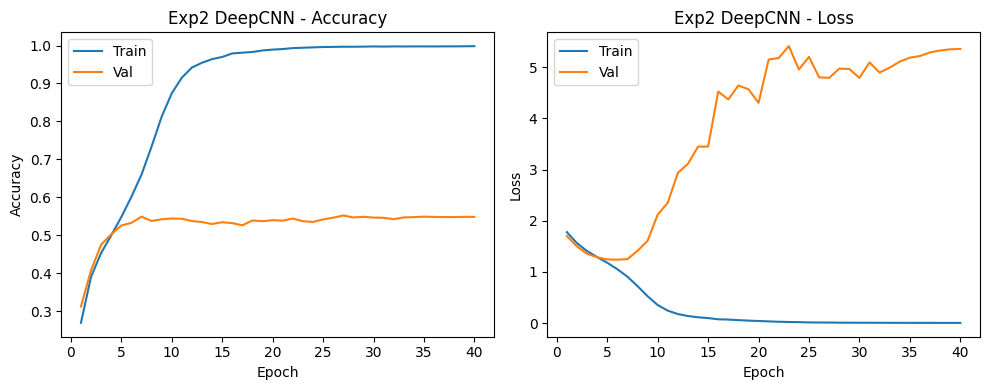

Key observation: train loss keeps dropping while val loss increases - overfitting confirmed.


In [10]:
# Experiment 2: DeepCNN
class DeepCNN(nn.Module):
    def __init__(self, num_classes=7):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1,   32,  3, padding=1), nn.ReLU(),
            nn.Conv2d(32,  32,  3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,  64,  3, padding=1), nn.ReLU(),
            nn.Conv2d(64,  64,  3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64,  128, 3, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 1024), nn.ReLU(),
            nn.Linear(1024, 512),          nn.ReLU(),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


print("=== Exp 2: DeepCNN (overfitting demo) ===")
forward_backward_check(DeepCNN(), DEVICE, 'DeepCNN')

train_loader, val_loader, test_loader = get_dataloaders(batch_size=64, augment=False)

config_exp2 = {
    'architecture': 'DeepCNN',
    'epochs': 40,
    'lr': 1e-3,
    'optimizer': 'adam',
    'weight_decay': 0.0,
    'batch_size': 64,
    'augmentation': False,
    'label_smoothing': 0.0,
    'early_stop_patience': 40,
    'expected_behavior': 'overfitting',
    'notes': 'Deep CNN without any regularisation. Train acc >> val acc. '
             'Gap widens monotonically - classic overfitting signature.'
}

hist2, acc2 = train_model(DeepCNN(), config_exp2, train_loader, val_loader, 'exp2_DeepCNN_overfit')
print(f"Exp2 best val acc: {acc2:.4f}")

plt.figure(figsize=(10, 4))
epochs_range = range(1, len(hist2['train_acc']) + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs_range, hist2['train_acc'], label='Train')
plt.plot(epochs_range, hist2['val_acc'],   label='Val')
plt.title('Exp2 DeepCNN - Accuracy')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(epochs_range, hist2['train_loss'], label='Train')
plt.plot(epochs_range, hist2['val_loss'],   label='Val')
plt.title('Exp2 DeepCNN - Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.savefig('exp2_overfit_curves.png', dpi=150)
plt.show()
print("Key observation: train loss keeps dropping while val loss increases - overfitting confirmed.")

=== Exp 3: MediumCNN (regularised) ===
Forward pass - output shape torch.Size([4, 7])
Backward pass - 24 tensors have gradients
Overfit check - loss 2.0351 -> 0.0014
Train: 22967, Val: 5742, Test: 7178



  exp3_MediumCNN_regularised
Ep   1/50 | Train 1.7235/0.3347 | Val 1.5806/0.4282 | Gap -0.0935
Ep   5/50 | Train 1.4405/0.5090 | Val 1.3530/0.5535 | Gap -0.0445
Ep  10/50 | Train 1.3652/0.5501 | Val 1.2787/0.5803 | Gap -0.0302
Ep  15/50 | Train 1.3145/0.5771 | Val 1.2369/0.6090 | Gap -0.0319
Ep  20/50 | Train 1.2765/0.5967 | Val 1.2024/0.6297 | Gap -0.0331
Ep  25/50 | Train 1.2409/0.6150 | Val 1.1814/0.6385 | Gap -0.0235
Ep  30/50 | Train 1.2164/0.6232 | Val 1.1665/0.6433 | Gap -0.0201
Ep  35/50 | Train 1.1908/0.6383 | Val 1.1629/0.6498 | Gap -0.0115
Ep  40/50 | Train 1.1762/0.6430 | Val 1.1521/0.6543 | Gap -0.0113
Ep  45/50 | Train 1.1658/0.6515 | Val 1.1479/0.6540 | Gap -0.0025
Ep  50/50 | Train 1.1611/0.6559 | Val 1.1493/0.6559 | Gap +0.0001


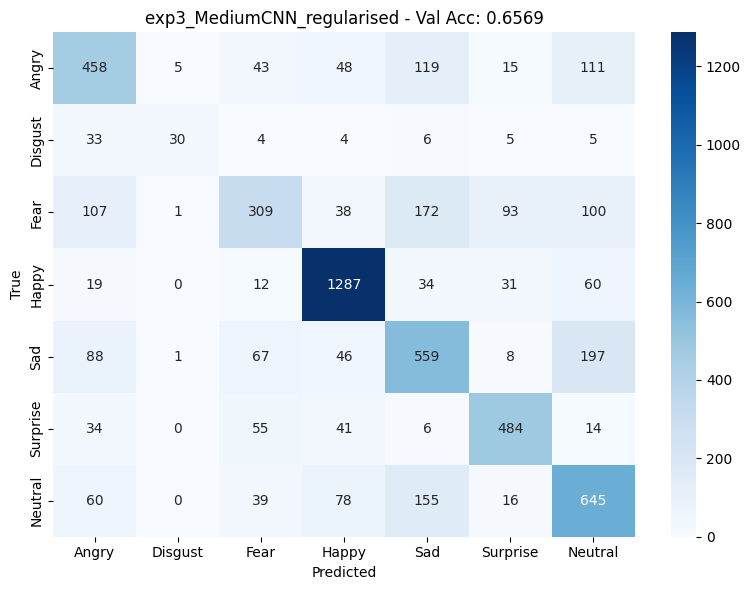


 Best val acc: 0.6569


epoch,▁▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,███████▇▇▇▇▇▇▆▆▆▆▅▅▅▄▄▄▄▃▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁
per_class/Angry_f1,▁
per_class/Disgust_f1,▁
per_class/Fear_f1,▁
per_class/Happy_f1,▁
per_class/Neutral_f1,▁
per_class/Sad_f1,▁
per_class/Surprise_f1,▁
train/acc,▁▃▄▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇▇▇█████████████
+4,...


Exp3 best val acc: 0.6569


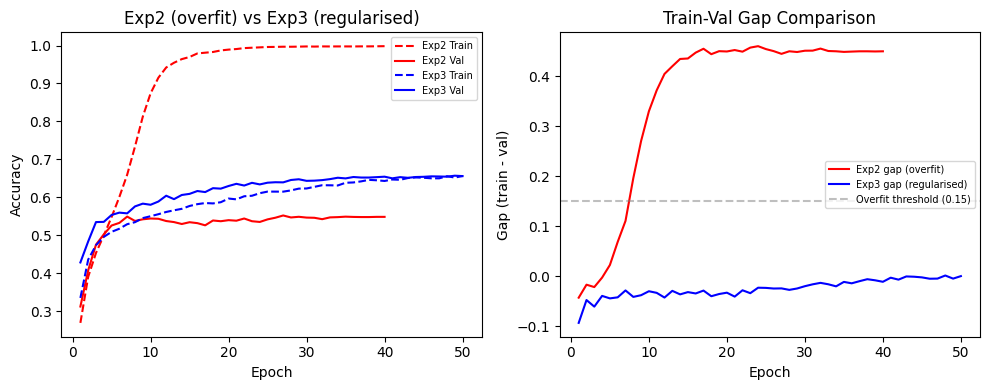

Exp2 final gap: +0.4498  |  Exp3 final gap: +0.0001


In [11]:
# Experiment 3: MediumCNN (Regularised)
class MediumCNN(nn.Module):

    def __init__(self, num_classes=7, dropout_rate=0.3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.1),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 3 * 3, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))


print("=== Exp 3: MediumCNN (regularised) ===")
forward_backward_check(MediumCNN(), DEVICE, 'MediumCNN')

train_loader, val_loader, test_loader = get_dataloaders(batch_size=64, augment=True)

config_exp3 = {
    'architecture': 'MediumCNN',
    'epochs': 50,
    'lr': 1e-3,
    'optimizer': 'adamw',
    'weight_decay': 1e-3,
    'batch_size': 64,
    'augmentation': True,
    'label_smoothing': 0.1,
    'dropout': 0.3,
    'early_stop_patience': 15,
    'expected_behavior': 'well_regularised',
    'notes': 'BatchNorm + Dropout + Augmentation + label smoothing. '
             'Train-val gap shrinks vs Exp2. Demonstrates regularisation working.'
}

hist3, acc3 = train_model(MediumCNN(dropout_rate=0.3), config_exp3,
                           train_loader, val_loader, 'exp3_MediumCNN_regularised')
print(f"Exp3 best val acc: {acc3:.4f}")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(hist2['train_acc']) + 1), hist2['train_acc'], label='Exp2 Train', linestyle='--', color='red')
plt.plot(range(1, len(hist2['val_acc'])   + 1), hist2['val_acc'],   label='Exp2 Val',   linestyle='-',  color='red')
plt.plot(range(1, len(hist3['train_acc']) + 1), hist3['train_acc'], label='Exp3 Train', linestyle='--', color='blue')
plt.plot(range(1, len(hist3['val_acc'])   + 1), hist3['val_acc'],   label='Exp3 Val',   linestyle='-',  color='blue')
plt.title('Exp2 (overfit) vs Exp3 (regularised)')
plt.xlabel('Epoch'); plt.ylabel('Accuracy')
plt.legend(fontsize=7)

plt.subplot(1, 2, 2)
gap2 = [t - v for t, v in zip(hist2['train_acc'], hist2['val_acc'])]
gap3 = [t - v for t, v in zip(hist3['train_acc'], hist3['val_acc'])]
plt.plot(range(1, len(gap2) + 1), gap2, label='Exp2 gap (overfit)',     color='red')
plt.plot(range(1, len(gap3) + 1), gap3, label='Exp3 gap (regularised)', color='blue')
plt.axhline(y=0.15, color='gray', linestyle='--', alpha=0.5, label='Overfit threshold (0.15)')
plt.title('Train-Val Gap Comparison')
plt.xlabel('Epoch'); plt.ylabel('Gap (train - val)')
plt.legend(fontsize=7)

plt.tight_layout()
plt.savefig('exp3_regularisation_comparison.png', dpi=150)
plt.show()
print(f"Exp2 final gap: {gap2[-1]:+.4f}  |  Exp3 final gap: {gap3[-1]:+.4f}")

=== Exp 4: MiniResNet (residual connections) ===
Forward pass - output shape torch.Size([4, 7])
Backward pass - 59 tensors have gradients
Overfit check - loss 1.8435 -> 0.0010
Train: 22967, Val: 5742, Test: 7178



  exp4_MiniResNet
Ep   1/60 | Train 1.7111/0.3455 | Val 1.6172/0.4115 | Gap -0.0661
Ep   5/60 | Train 1.3367/0.5565 | Val 1.4129/0.5275 | Gap +0.0290
Ep  10/60 | Train 1.2230/0.6189 | Val 1.2339/0.6014 | Gap +0.0176
Ep  15/60 | Train 1.1547/0.6527 | Val 1.1833/0.6456 | Gap +0.0071
Ep  20/60 | Train 1.0979/0.6846 | Val 1.1726/0.6412 | Gap +0.0434
Ep  25/60 | Train 1.0416/0.7121 | Val 1.1504/0.6581 | Gap +0.0540
Ep  30/60 | Train 0.9774/0.7510 | Val 1.1556/0.6625 | Gap +0.0885
Ep  35/60 | Train 0.9168/0.7808 | Val 1.1659/0.6794 | Gap +0.1014
Ep  40/60 | Train 0.8578/0.8073 | Val 1.1790/0.6823 | Gap +0.1250
Ep  45/60 | Train 0.8094/0.8354 | Val 1.2034/0.6789 | Gap +0.1565
Ep  50/60 | Train 0.7694/0.8548 | Val 1.2147/0.6806 | Gap +0.1742
Ep  55/60 | Train 0.7561/0.8597 | Val 1.2135/0.6816 | Gap +0.1780
  Early stop at epoch 58


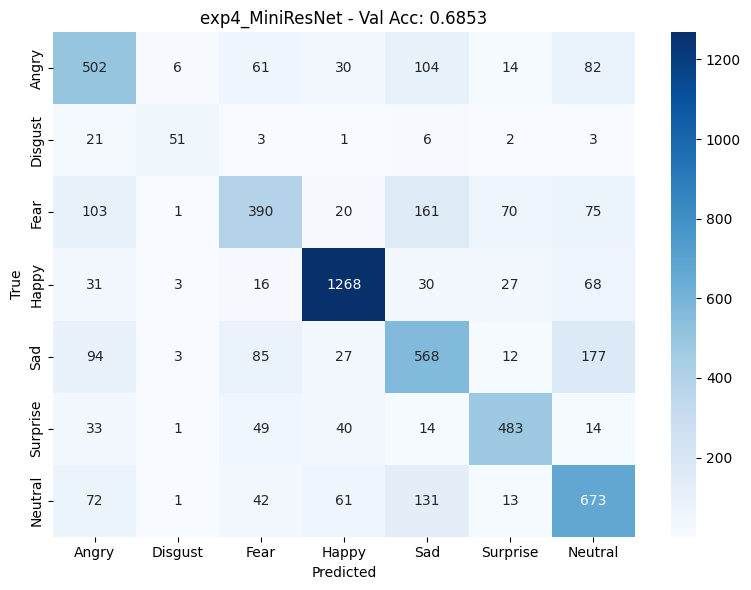


 Best val acc: 0.6853


epoch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇██
lr,███████▇▇▇▇▆▆▆▆▅▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▂▁▁▁▁▁▁
per_class/Angry_f1,▁
per_class/Disgust_f1,▁
per_class/Fear_f1,▁
per_class/Happy_f1,▁
per_class/Neutral_f1,▁
per_class/Sad_f1,▁
per_class/Surprise_f1,▁
train/acc,▁▃▃▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▇▇▇▇▇▇▇▇▇▇██████████
+4,...


Exp4 best val acc: 0.6853


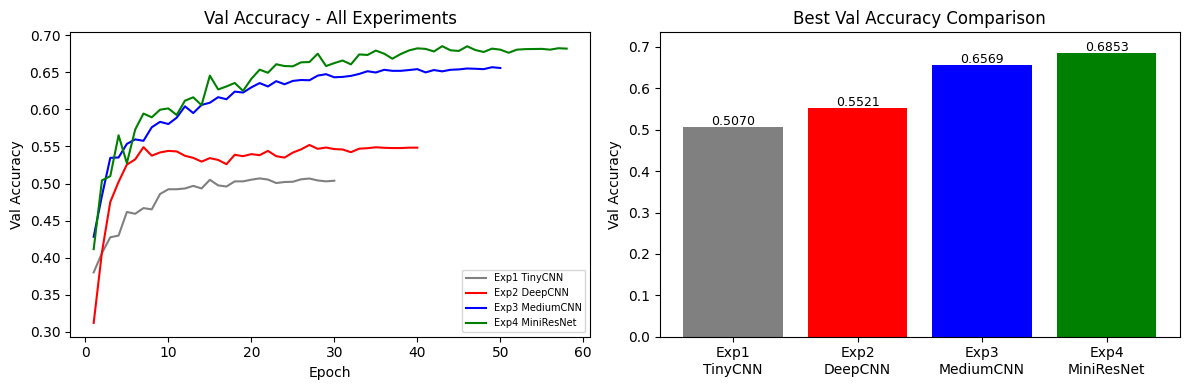


So far - Exp1: 0.5070 | Exp2: 0.5521 | Exp3: 0.6569 | Exp4: 0.6853


In [12]:
# Experiment 4: MiniResNet (Residual Connections)
class ResidualBlock(nn.Module):

    def __init__(self, in_channels, out_channels, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3,
                               stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3,
                               padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_channels)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        return F.relu(out)


class MiniResNet(nn.Module):

    def __init__(self, num_classes=7):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(),
        )
        self.layer1 = self._make_layer(32,  64,  blocks=2, stride=2)
        self.layer2 = self._make_layer(64,  128, blocks=2, stride=2)
        self.layer3 = self._make_layer(128, 256, blocks=2, stride=2)
        self.layer4 = self._make_layer(256, 512, blocks=1, stride=2)

        self.global_avg_pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(512, num_classes)

    def _make_layer(self, in_ch, out_ch, blocks, stride):
        layers = [ResidualBlock(in_ch, out_ch, stride)]
        for _ in range(1, blocks):
            layers.append(ResidualBlock(out_ch, out_ch, 1))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.global_avg_pool(x)
        x = x.view(x.size(0), -1)
        x = self.dropout(x)
        return self.fc(x)


print("=== Exp 4: MiniResNet (residual connections) ===")
forward_backward_check(MiniResNet(), DEVICE, 'MiniResNet')

train_loader, val_loader, test_loader = get_dataloaders(batch_size=64, augment=True)

config_exp4 = {
    'architecture': 'MiniResNet',
    'epochs': 60,
    'lr': 5e-4,
    'optimizer': 'adamw',
    'weight_decay': 5e-4,
    'batch_size': 64,
    'augmentation': True,
    'label_smoothing': 0.1,
    'dropout': 0.4,
    'early_stop_patience': 15,
    'expected_behavior': 'best_custom',
    'notes': 'Residual blocks help gradient flow. '
             'Global avg pooling instead of flatten - fewer params, less overfitting. '
             'Lower LR (5e-4) than prev experiments suits deeper network.'
}

hist4, acc4 = train_model(MiniResNet(), config_exp4,
                           train_loader, val_loader, 'exp4_MiniResNet')
print(f"Exp4 best val acc: {acc4:.4f}")

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
for hist, name, color in [
    (hist1, 'Exp1 TinyCNN',    'gray'),
    (hist2, 'Exp2 DeepCNN',    'red'),
    (hist3, 'Exp3 MediumCNN',  'blue'),
    (hist4, 'Exp4 MiniResNet', 'green'),
]:
    plt.plot(range(1, len(hist['val_acc']) + 1), hist['val_acc'],
             label=name, color=color)
plt.title('Val Accuracy - All Experiments')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy')
plt.legend(fontsize=7)

plt.subplot(1, 2, 2)
accs  = [acc1, acc2, acc3, acc4]
names = ['Exp1\nTinyCNN', 'Exp2\nDeepCNN', 'Exp3\nMediumCNN', 'Exp4\nMiniResNet']
colors = ['gray', 'red', 'blue', 'green']
bars = plt.bar(names, accs, color=colors)
for bar, val in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontsize=9)
plt.title('Best Val Accuracy Comparison')
plt.ylabel('Val Accuracy')
plt.ylim(0, max(accs) + 0.05)

plt.tight_layout()
plt.savefig('exp4_comparison.png', dpi=150)
plt.show()
print(f"\nSo far - Exp1: {acc1:.4f} | Exp2: {acc2:.4f} | Exp3: {acc3:.4f} | Exp4: {acc4:.4f}")

=== Exp 5: Transfer Learning ResNet18 ===
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 131MB/s]


Forward pass - output shape torch.Size([4, 7])
Backward pass - 64 tensors have gradients
Overfit check - loss 2.0772 -> 0.0000
Train: 22967, Val: 5742, Test: 7178



  exp5_TransferResNet18
Ep   1/40 | Train 1.6318/0.4034 | Val 1.4177/0.5158 | Gap -0.1125
Ep   5/40 | Train 1.2962/0.5852 | Val 1.2421/0.6064 | Gap -0.0212
Ep  10/40 | Train 1.1776/0.6520 | Val 1.2093/0.6280 | Gap +0.0240
Ep  15/40 | Train 1.0713/0.7056 | Val 1.2113/0.6405 | Gap +0.0651
Ep  20/40 | Train 0.9564/0.7620 | Val 1.2222/0.6480 | Gap +0.1140
Ep  25/40 | Train 0.8578/0.8091 | Val 1.2665/0.6442 | Gap +0.1649
Ep  30/40 | Train 0.7778/0.8519 | Val 1.3154/0.6452 | Gap +0.2067
Ep  35/40 | Train 0.7319/0.8743 | Val 1.3371/0.6461 | Gap +0.2281
Ep  40/40 | Train 0.7183/0.8815 | Val 1.3429/0.6508 | Gap +0.2307
  Early stop at epoch 40


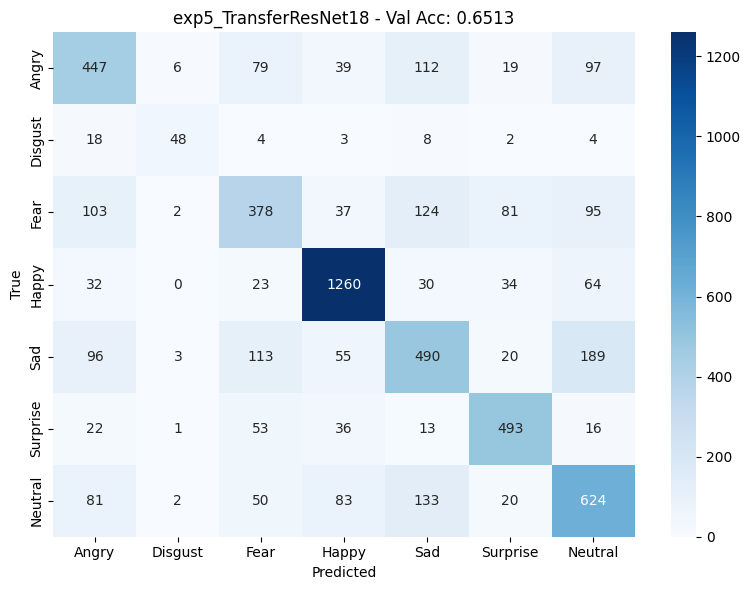


 Best val acc: 0.6513


epoch,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
lr,██████▇▇▇▇▇▇▆▆▆▆▅▅▅▅▄▄▄▃▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁
per_class/Angry_f1,▁
per_class/Disgust_f1,▁
per_class/Fear_f1,▁
per_class/Happy_f1,▁
per_class/Neutral_f1,▁
per_class/Sad_f1,▁
per_class/Surprise_f1,▁
train/acc,▁▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇▇▇▇███████████
+4,...


Exp5 best val acc: 0.6513


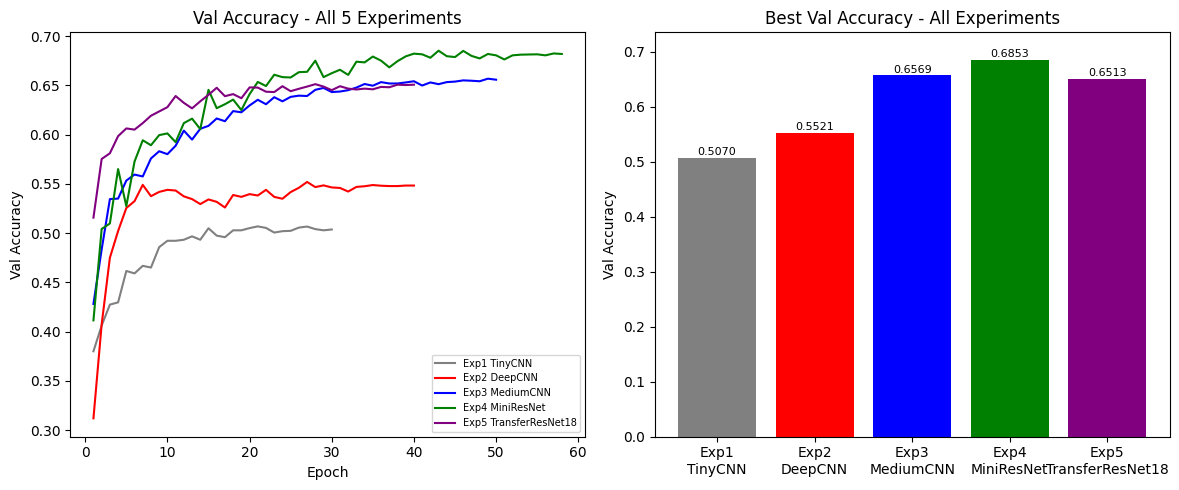


  FINAL RESULTS
  Exp1 TinyCNN              0.5070  ████████████████████
  Exp2 DeepCNN              0.5521  ██████████████████████
  Exp3 MediumCNN            0.6569  ██████████████████████████
  Exp4 MiniResNet           0.6853  ███████████████████████████
  Exp5 TransferResNet18     0.6513  ██████████████████████████

  Best: Exp4 MiniResNet (0.6853)


In [13]:
# Experiment 5: Transfer Learning - ResNet18
import torchvision.models as models

class TransferResNet18(nn.Module):

    def __init__(self, num_classes=7):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

        original_weight = base.conv1.weight.data
        base.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        base.conv1.weight.data = original_weight.mean(dim=1, keepdim=True)

        in_features = base.fc.in_features
        base.fc = nn.Sequential(
            nn.Dropout(0.4),
            nn.Linear(in_features, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes),
        )
        self.model = base

    def forward(self, x):
        return self.model(x)


print("=== Exp 5: Transfer Learning ResNet18 ===")
forward_backward_check(TransferResNet18(), DEVICE, 'TransferResNet18')

train_loader, val_loader, test_loader = get_dataloaders(batch_size=32, augment=True)

config_exp5 = {
    'architecture': 'TransferResNet18',
    'pretrained': 'ImageNet1K',
    'epochs': 40,
    'lr': 1e-4,
    'optimizer': 'adamw',
    'weight_decay': 1e-4,
    'batch_size': 32,
    'augmentation': True,
    'label_smoothing': 0.1,
    'dropout': 0.4,
    'early_stop_patience': 12,
    'expected_behavior': 'best_overall',
    'notes': 'ImageNet pretrained ResNet18 finetuned for FER. '
             'Conv1 adapted for grayscale via mean of RGB weights. '
             'Lower LR (1e-4) avoids destroying pretrained features. '
             'Smaller batch (32) due to larger model size.'
}

hist5, acc5 = train_model(TransferResNet18(), config_exp5,
                           train_loader, val_loader, 'exp5_TransferResNet18')
print(f"Exp5 best val acc: {acc5:.4f}")

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for hist, name, color in [
    (hist1, 'Exp1 TinyCNN',         'gray'),
    (hist2, 'Exp2 DeepCNN',         'red'),
    (hist3, 'Exp3 MediumCNN',       'blue'),
    (hist4, 'Exp4 MiniResNet',      'green'),
    (hist5, 'Exp5 TransferResNet18','purple'),
]:
    plt.plot(range(1, len(hist['val_acc']) + 1), hist['val_acc'],
             label=name, color=color)
plt.title('Val Accuracy - All 5 Experiments')
plt.xlabel('Epoch'); plt.ylabel('Val Accuracy')
plt.legend(fontsize=7)

plt.subplot(1, 2, 2)
all_accs  = [acc1, acc2, acc3, acc4, acc5]
all_names = ['Exp1\nTinyCNN', 'Exp2\nDeepCNN', 'Exp3\nMediumCNN',
             'Exp4\nMiniResNet', 'Exp5\nTransferResNet18']
all_colors = ['gray', 'red', 'blue', 'green', 'purple']
bars = plt.bar(all_names, all_accs, color=all_colors)
for bar, val in zip(bars, all_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', fontsize=8)
plt.title('Best Val Accuracy - All Experiments')
plt.ylabel('Val Accuracy')
plt.ylim(0, max(all_accs) + 0.05)

plt.tight_layout()
plt.savefig('exp5_final_comparison.png', dpi=150)
plt.show()

print(f"\n{'='*55}")
print(f"  FINAL RESULTS")
print(f"{'='*55}")
for name, acc in zip(all_names, all_accs):
    bar = '█' * int(acc * 40)
    print(f"  {name.replace(chr(10), ' '):<25} {acc:.4f}  {bar}")
best_idx = all_accs.index(max(all_accs))
print(f"\n  Best: {all_names[best_idx].replace(chr(10), ' ')} ({max(all_accs):.4f})")

In [14]:
import pandas as pd

results_df = pd.DataFrame({
    'Experiment':       ['Exp1 TinyCNN', 'Exp2 DeepCNN', 'Exp3 MediumCNN',
                         'Exp4 MiniResNet', 'Exp5 TransferResNet18'],
    'Best Val Acc':     [acc1, acc2, acc3, acc4, acc5],
    'Expected':         ['underfitting', 'overfitting', 'well_regularised',
                         'best_custom', 'best_overall'],
    'Augmentation':     [False, False, True, True, True],
    'Optimizer':        ['adam', 'adam', 'adamw', 'adamw', 'adamw'],
    'LR':               [1e-3, 1e-3, 1e-3, 5e-4, 1e-4],
})
print(results_df.to_string(index=False))


           Experiment  Best Val Acc         Expected  Augmentation Optimizer     LR
         Exp1 TinyCNN      0.506966     underfitting         False      adam 0.0010
         Exp2 DeepCNN      0.552072      overfitting         False      adam 0.0010
       Exp3 MediumCNN      0.656914 well_regularised          True     adamw 0.0010
      Exp4 MiniResNet      0.685301      best_custom          True     adamw 0.0005
Exp5 TransferResNet18      0.651341     best_overall          True     adamw 0.0001


In [15]:
best_model = TransferResNet18().to(DEVICE)
best_model.load_state_dict(
    torch.load('checkpoints/best_exp5_TransferResNet18.pth', map_location=DEVICE)
)
best_model.eval()

test_loader_sub, _, _ = get_dataloaders(batch_size=64, augment=False)
from torch.utils.data import DataLoader
test_df_raw = pd.read_csv('test.csv')
test_dataset_sub = FERDataset(test_df_raw, transform=None, has_labels=False)
test_loader_sub  = DataLoader(test_dataset_sub, batch_size=64, shuffle=False, num_workers=2)

all_preds = []
with torch.no_grad():
    for images, _ in test_loader_sub:
        images = images.to(DEVICE)
        outputs = best_model(images)
        preds = outputs.argmax(1)
        all_preds.extend(preds.cpu().numpy())

submission = pd.DataFrame({
    'id':      range(1, len(all_preds) + 1),
    'emotion': all_preds,
})
submission.to_csv('submission.csv', index=False)
print(f"Saved submission.csv - {len(submission)} rows")
print(submission['emotion'].value_counts().sort_index()
      .rename(index={i: EMOTION_LABELS[i] for i in range(7)}))

Train: 22967, Val: 5742, Test: 7178
Saved submission.csv - 7178 rows
emotion
Angry        986
Disgust       86
Fear         898
Happy       1867
Sad         1131
Surprise     889
Neutral     1321
Name: count, dtype: int64


In [16]:
gitignore = """checkpoints/
wandb/
*.zip
*.tar.gz
sample_data/
__pycache__/
*.pyc
.ipynb_checkpoints/
"""
with open('.gitignore', 'w') as f:
    f.write(gitignore)

In [18]:
!find /content -name "*.ipynb" 2>/dev/null

In [27]:
!git filter-branch --force --index-filter \
  "git rm --cached --ignore-unmatch train.csv test.csv icml_face_data.csv example_submission.csv" \
  --prune-empty --tag-name-filter cat -- --all

TOKEN = userdata.get('GITHUB_TOKEN')
REPO  = f"https://{TOKEN}@github.com/lizikutchava/ml_assn4"
!git push {REPO} main --force

	 rewrites.  Hit Ctrl-C before proceeding to abort, then use an
	 alternative filtering tool such as 'git filter-repo'
	 (https://github.com/newren/git-filter-repo/) instead.  See the
	 filter-branch manual page for more details; to squelch this warning,
	 set FILTER_BRANCH_SQUELCH_WARNING=1.
Proceeding with filter-branch...

Rewrite 8634ba3c1ae11ee832e4805f0956c7c0dac38c99 (1/3) (0 seconds passed, remaining 0 predicted)    rm 'example_submission.csv'
rm 'icml_face_data.csv'
rm 'test.csv'
rm 'train.csv'
Rewrite d2f5e2a84885de7f7d2b5fee8d83e87eaad9a74b (3/3) (0 seconds passed, remaining 0 predicted)    
Ref 'refs/heads/main' was rewritten
Enumerating objects: 33, done.
Counting objects: 100% (33/33), done.
Delta compression using up to 2 threads
Compressing objects: 100% (26/26), done.
Writing objects: 100% (33/33), 363.19 KiB | 13.45 MiB/s, done.
Total 33 (delta 8), reused 0 (delta 0), pack-reused 0
remote: Resolving deltas: 100% (8/8), done.
To https://github.com/lizikutchava/ml_assn4

In [34]:
from google.colab import drive
drive.mount('/content/drive')

!find /content/drive/MyDrive -name "*.ipynb" 2>/dev/null

Mounted at /content/drive
/content/drive/MyDrive/Classroom/Natural Language Processing (Spring 2026)/lkuch23.ipynb
/content/drive/MyDrive/cs231n/assignments/assignment2/assignment2/FullyConnectedNets.ipynb
/content/drive/MyDrive/cs231n/assignments/assignment2/assignment2/Dropout.ipynb
/content/drive/MyDrive/cs231n/assignments/assignment2/assignment2/BatchNormalization.ipynb
/content/drive/MyDrive/cs231n/assignments/assignment2/assignment2/PyTorch.ipynb
/content/drive/MyDrive/cs231n/assignments/assignment2/assignment2/ConvolutionalNetworks.ipynb
/content/drive/MyDrive/cs231n/assignments/assignment2/assignment2/collect_submission.ipynb
/content/drive/MyDrive/cs231n/assignments/assignment2/__MACOSX/assignment2/._FullyConnectedNets.ipynb
/content/drive/MyDrive/cs231n/assignments/assignment2/__MACOSX/assignment2/._collect_submission.ipynb
/content/drive/MyDrive/cs231n/assignments/assignment2/__MACOSX/assignment2/._ConvolutionalNetworks.ipynb
/content/drive/MyDrive/cs231n/assignments/assignm